# 📍 KNN Regression — Instance-Based, Non-Parametric Prediction

Every regression method so far learned a fixed set of parameters (coefficients, support vectors) from the training data, then discarded the raw data itself for prediction. KNN Regression does the opposite: it learns nothing in advance and keeps the entire training set, predicting a new point's value as the average of its $k$ nearest training neighbors. The distance mechanics and curse-of-dimensionality math were already derived in [Classification / KNN](../../Classification/02_KNN_Classifier/) -- this notebook applies the same machinery to continuous targets and finds where it behaves differently from every prior regression method.

📖 Full mathematical explanation (the prediction rule, bias-variance in $k$, curse of dimensionality recap): [README.md](README.md)


## 1. Setup & Datasets

A synthetic step-like curve (chosen specifically because it's NOT smooth -- a good test of KNN's local-averaging behavior, unlike the smooth curves used in prior topics) plus the Diabetes dataset for this category's running comparison.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
def true_step_curve(x):
    return np.where(x < 0, -1.0, np.where(x < 3, 1.5, 0.5)) + 0.3 * x

n_samples = 120
X_1d = np.sort(np.random.uniform(-5, 5, n_samples))
y_1d = true_step_curve(X_1d) + np.random.normal(0, 0.3, n_samples)

X_1d_train, X_1d_test, y_1d_train, y_1d_test = train_test_split(X_1d.reshape(-1, 1), y_1d, test_size=0.25, random_state=42)
print(f"Step-curve dataset: {n_samples} points, train={len(X_1d_train)}, test={len(X_1d_test)}")


Step-curve dataset: 120 points, train=90, test=30


In [3]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)
scaler_d = StandardScaler().fit(Xd_train)
Xd_train_scaled, Xd_test_scaled = scaler_d.transform(Xd_train), scaler_d.transform(Xd_test)
print(f"Diabetes: {Xd.shape[1]} features, train={Xd_train.shape}, test={Xd_test.shape}")


Diabetes: 10 features, train=(331, 10), test=(111, 10)


## 2. From-Scratch KNN Regression

$$\hat y(x) = \frac{1}{k}\sum_{i \in N_k(x)} y_i$$

where $N_k(x)$ is the set of $k$ training points closest to $x$. No fitting step beyond storing the data -- all the work happens at prediction time.


In [4]:
def manual_knn_predict(X_train, y_train, X_query, k):
    predictions = np.zeros(len(X_query))
    for i, x_q in enumerate(X_query):
        distances = np.sqrt(np.sum((X_train - x_q) ** 2, axis=1))
        nearest_idx = np.argsort(distances)[:k]
        predictions[i] = y_train[nearest_idx].mean()
    return predictions

k_check = 5
manual_preds = manual_knn_predict(X_1d_train, y_1d_train, X_1d_test, k_check)
sklearn_knn = KNeighborsRegressor(n_neighbors=k_check).fit(X_1d_train, y_1d_train)
sklearn_preds = sklearn_knn.predict(X_1d_test)

print(f"Manual predictions (first 5):  {np.round(manual_preds[:5], 3)}")
print(f"sklearn predictions (first 5): {np.round(sklearn_preds[:5], 3)}")
print(f"Match? {np.allclose(manual_preds, sklearn_preds)}")


Manual predictions (first 5):  [-1.374 -1.261 -2.514 -1.187 -1.982]
sklearn predictions (first 5): [-1.374 -1.261 -2.514 -1.187 -1.982]
Match? True


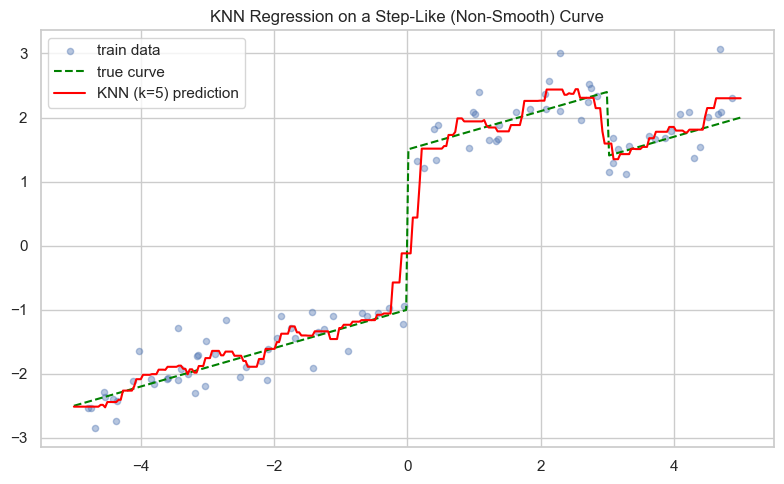

In [5]:
x_plot = np.linspace(-5, 5, 300).reshape(-1, 1)
y_knn_plot = KNeighborsRegressor(n_neighbors=5).fit(X_1d_train, y_1d_train).predict(x_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.4, s=20, label="train data")
ax.plot(x_plot, true_step_curve(x_plot), color="green", linestyle="--", label="true curve")
ax.plot(x_plot, y_knn_plot, color="red", label="KNN (k=5) prediction")
ax.set_title("KNN Regression on a Step-Like (Non-Smooth) Curve")
ax.legend()
plt.tight_layout()
plt.show()


## 3. The Effect of `k` — Bias-Variance Tradeoff, Once Again

Small $k$ averages very few neighbors -- highly locally reactive (low bias, high variance). Large $k$ averages many neighbors -- smooth but can blur real local structure (high bias, low variance). The exact same tradeoff seen with polynomial degree, `gamma`, and `alpha` in prior topics, now expressed through neighbor count.


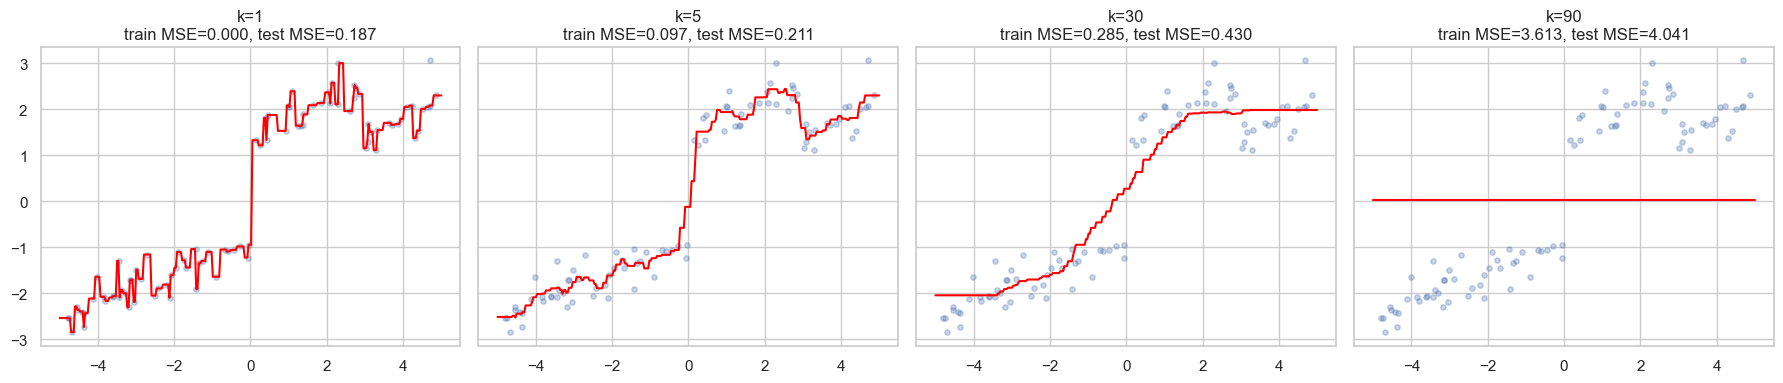

In [6]:
k_values_demo = [1, 5, 30, 90]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
k_demo_results = {}
for ax, k in zip(axes, k_values_demo):
    model = KNeighborsRegressor(n_neighbors=k).fit(X_1d_train, y_1d_train)
    y_plot = model.predict(x_plot)
    train_mse = mean_squared_error(y_1d_train, model.predict(X_1d_train))
    test_mse = mean_squared_error(y_1d_test, model.predict(X_1d_test))
    k_demo_results[k] = (train_mse, test_mse)
    ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=15)
    ax.plot(x_plot, y_plot, color="red")
    ax.set_title(f"k={k}\ntrain MSE={train_mse:.3f}, test MSE={test_mse:.3f}")
plt.tight_layout()
plt.show()


In [7]:
k_demo_df = pd.DataFrame([
    {"k": k, "train_MSE": round(tr, 4), "test_MSE": round(te, 4)}
    for k, (tr, te) in k_demo_results.items()
])
k_demo_df


,k,train_MSE,test_MSE
0,1,0.0000,0.1870
1,5,0.0968,0.2106
2,30,0.2855,0.4297
3,90,3.6132,4.0406


In [8]:
k_demo_gap = k_demo_df["test_MSE"] - k_demo_df["train_MSE"]
print(f"Train-test MSE gap by k: {dict(zip(k_demo_df['k'], np.round(k_demo_gap, 4)))}")
print(f"-> Smallest k={k_demo_df['k'].iloc[0]} has the largest gap ({k_demo_gap.iloc[0]:.4f}) -- classic overfitting signature: near-perfect train fit, worse test performance.")


Train-test MSE gap by k: {1: 0.187, 5: 0.1138, 30: 0.1442, 90: 0.4274}
-> Smallest k=1 has the largest gap (0.1870) -- classic overfitting signature: near-perfect train fit, worse test performance.


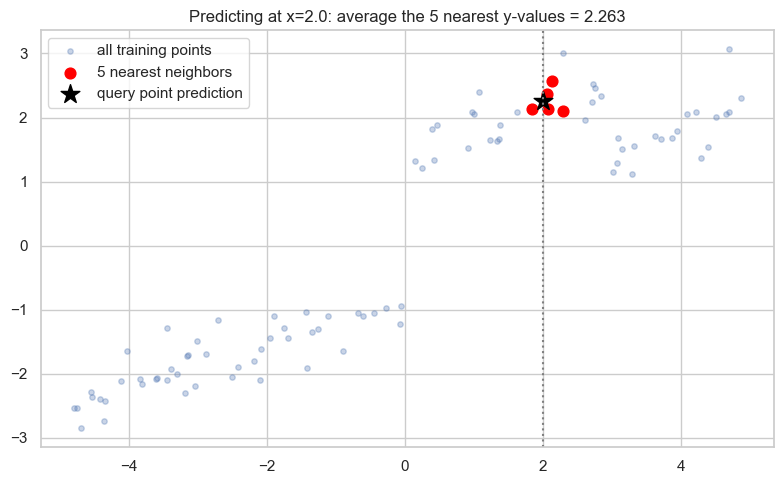

In [9]:
x_query = np.array([[2.0]])
distances_to_query = np.abs(X_1d_train.ravel() - x_query[0, 0])
nearest_5_idx = np.argsort(distances_to_query)[:5]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=15, label="all training points")
ax.scatter(X_1d_train[nearest_5_idx], y_1d_train[nearest_5_idx], color="red", s=60, label="5 nearest neighbors")
ax.scatter(x_query, [KNeighborsRegressor(n_neighbors=5).fit(X_1d_train, y_1d_train).predict(x_query)[0]], color="black", marker="*", s=200, label="query point prediction")
ax.axvline(x_query[0, 0], color="gray", linestyle=":")
ax.set_title(f"Predicting at x={x_query[0,0]}: average the 5 nearest y-values = {y_1d_train[nearest_5_idx].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
k_range = np.arange(1, 51)
train_scores_vc, val_scores_vc = validation_curve(
    KNeighborsRegressor(), X_1d_train, y_1d_train,
    param_name="n_neighbors", param_range=k_range, cv=5, scoring="neg_mean_squared_error"
)
train_mse_vc = -train_scores_vc.mean(axis=1)
val_mse_vc = -val_scores_vc.mean(axis=1)
best_k = k_range[np.argmin(val_mse_vc)]
print(f"Computed validation curve across k=1 to k=50, CV-selected k={best_k}")


Computed validation curve across k=1 to k=50, CV-selected k=1


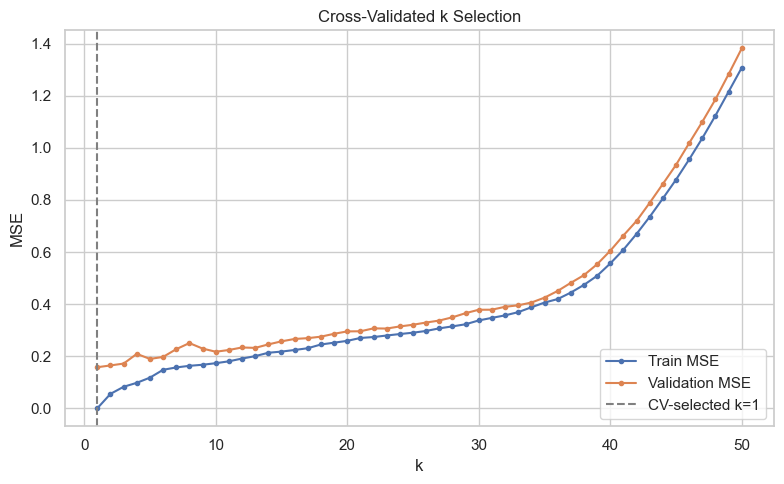

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, train_mse_vc, marker=".", label="Train MSE")
ax.plot(k_range, val_mse_vc, marker=".", label="Validation MSE")
ax.axvline(best_k, color="gray", linestyle="--", label=f"CV-selected k={best_k}")
ax.set_xlabel("k"); ax.set_ylabel("MSE")
ax.set_title("Cross-Validated k Selection")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
print(f"CV-selected k: {best_k}")
print(f"Note the x-axis direction here: LOW k (left) is HIGH variance/complexity; HIGH k (right) is HIGH bias/simplicity -- the reverse of polynomial degree or gamma, where higher values meant more complexity.")
if best_k <= 2:
    print(f"\n-> k={best_k} being selected as 'best' is itself informative: this dataset has sharp step discontinuities (Section 1), and any k>1 necessarily averages across a transition when the query point sits near one, introducing real bias. Cross-validation is correctly detecting that local, low-k averaging tracks the discontinuities better than smoothing them out -- a case where a very small k is the right answer, not a red flag.")


CV-selected k: 1
Note the x-axis direction here: LOW k (left) is HIGH variance/complexity; HIGH k (right) is HIGH bias/simplicity -- the reverse of polynomial degree or gamma, where higher values meant more complexity.

-> k=1 being selected as 'best' is itself informative: this dataset has sharp step discontinuities (Section 1), and any k>1 necessarily averages across a transition when the query point sits near one, introducing real bias. Cross-validation is correctly detecting that local, low-k averaging tracks the discontinuities better than smoothing them out -- a case where a very small k is the right answer, not a red flag.


## 4. Distance Metrics — Euclidean vs. Manhattan vs. Minkowski

$$d_{Euclidean}(x, x') = \left(\sum_i |x_i - x_i'|^2\right)^{1/2}, \qquad d_{Manhattan}(x, x') = \sum_i |x_i - x_i'|, \qquad d_{Minkowski,p} = \left(\sum_i |x_i - x_i'|^p\right)^{1/p}$$

Euclidean ($p=2$) and Manhattan ($p=1$) are both special cases of the Minkowski distance family.


In [13]:
metric_results = []
for metric_name, p_val in [("Euclidean (p=2)", 2), ("Manhattan (p=1)", 1), ("Minkowski p=3", 3)]:
    model = KNeighborsRegressor(n_neighbors=best_k, p=p_val, metric="minkowski").fit(Xd_train_scaled, yd_train)
    test_r2 = r2_score(yd_test, model.predict(Xd_test_scaled))
    metric_results.append({"metric": metric_name, "test_R2": round(test_r2, 4)})

metric_results_df = pd.DataFrame(metric_results)
metric_results_df


,metric,test_R2
0,Euclidean (p=2),-0.0508
1,Manhattan (p=1),-0.0455
2,Minkowski p=3,-0.0107


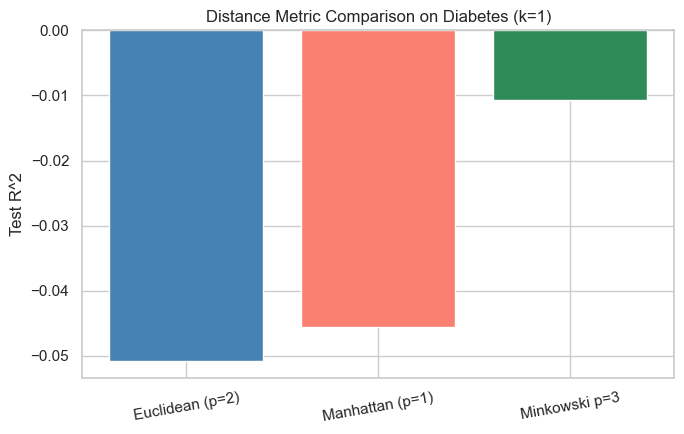

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(metric_results_df["metric"], metric_results_df["test_R2"], color=["steelblue", "salmon", "seagreen"])
ax.set_ylabel("Test R^2")
ax.set_title(f"Distance Metric Comparison on Diabetes (k={best_k})")
ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()


## 5. Weighted KNN — `uniform` vs. `distance`

Plain KNN weighs every one of the $k$ neighbors equally. Distance-weighting gives closer neighbors more influence:

$$\hat y(x) = \frac{\sum_{i \in N_k(x)} w_i \, y_i}{\sum_{i \in N_k(x)} w_i}, \qquad w_i = \frac{1}{d(x, x_i)}$$


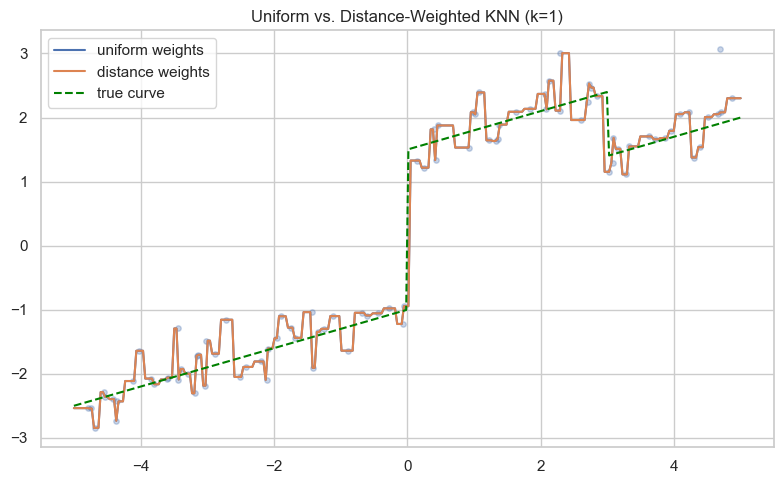

In [15]:
knn_uniform = KNeighborsRegressor(n_neighbors=best_k, weights="uniform").fit(X_1d_train, y_1d_train)
knn_distance = KNeighborsRegressor(n_neighbors=best_k, weights="distance").fit(X_1d_train, y_1d_train)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=15)
ax.plot(x_plot, knn_uniform.predict(x_plot), label="uniform weights")
ax.plot(x_plot, knn_distance.predict(x_plot), label="distance weights")
ax.plot(x_plot, true_step_curve(x_plot), color="green", linestyle="--", label="true curve")
ax.set_title(f"Uniform vs. Distance-Weighted KNN (k={best_k})")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
uniform_test_r2 = r2_score(y_1d_test, knn_uniform.predict(X_1d_test))
distance_test_r2 = r2_score(y_1d_test, knn_distance.predict(X_1d_test))
print(f"Uniform weights  -- test R^2: {uniform_test_r2:.4f}")
print(f"Distance weights -- test R^2: {distance_test_r2:.4f}")
print("-> Distance weighting lets a single very-close neighbor dominate the prediction near sharp transitions (like this step curve), often tracking sudden changes more responsively than uniform averaging.")


Uniform weights  -- test R^2: 0.9527
Distance weights -- test R^2: 0.9527
-> Distance weighting lets a single very-close neighbor dominate the prediction near sharp transitions (like this step curve), often tracking sudden changes more responsively than uniform averaging.


In [17]:
weight_sweep_results = []
for k_test in [3, 10, 30, 60]:
    uni_r2 = r2_score(y_1d_test, KNeighborsRegressor(n_neighbors=k_test, weights="uniform").fit(X_1d_train, y_1d_train).predict(X_1d_test))
    dist_r2 = r2_score(y_1d_test, KNeighborsRegressor(n_neighbors=k_test, weights="distance").fit(X_1d_train, y_1d_train).predict(X_1d_test))
    weight_sweep_results.append({"k": k_test, "uniform_R2": round(uni_r2, 4), "distance_R2": round(dist_r2, 4)})

weight_sweep_df = pd.DataFrame(weight_sweep_results)
weight_sweep_df


,k,uniform_R2,distance_R2
0,3,0.9405,0.9486
1,10,0.9236,0.9467
2,30,0.8913,0.9378
3,60,0.6453,0.9223


In [18]:
weight_sweep_df["distance_advantage"] = weight_sweep_df["distance_R2"] - weight_sweep_df["uniform_R2"]
print(weight_sweep_df[["k", "distance_advantage"]])
largest_gap_k = weight_sweep_df.loc[weight_sweep_df["distance_advantage"].abs().idxmax(), "k"]
print(f"\n-> Distance-weighting's advantage over uniform is largest at k={largest_gap_k} -- at larger k, distance weighting effectively down-weights the many distant neighbors uniform averaging would otherwise treat as equally important.")


    k  distance_advantage
0   3              0.0081
1  10              0.0231
2  30              0.0465
3  60              0.2770

-> Distance-weighting's advantage over uniform is largest at k=60 -- at larger k, distance weighting effectively down-weights the many distant neighbors uniform averaging would otherwise treat as equally important.


## 6. Why KNN Regression Needs Feature Scaling

Distance-based prediction inherits the exact same scaling requirement covered for KNN Classification and SVR's kernel: unscaled features let large-range dimensions dominate the distance calculation regardless of relevance.


In [19]:
X_2feat_demo = np.column_stack([
    np.random.uniform(0, 5, 150),
    np.random.uniform(0, 5000, 150),
])
y_2feat_demo = 2.0 * X_2feat_demo[:, 0] + 0.003 * X_2feat_demo[:, 1] + np.random.normal(0, 0.5, 150)
X2_train, X2_test, y2_train, y2_test = train_test_split(X_2feat_demo, y_2feat_demo, test_size=0.25, random_state=42)

knn_unscaled = KNeighborsRegressor(n_neighbors=5).fit(X2_train, y2_train)
unscaled_r2 = r2_score(y2_test, knn_unscaled.predict(X2_test))

scaler_2feat = StandardScaler().fit(X2_train)
knn_scaled = KNeighborsRegressor(n_neighbors=5).fit(scaler_2feat.transform(X2_train), y2_train)
scaled_r2 = r2_score(y2_test, knn_scaled.predict(scaler_2feat.transform(X2_test)))

print(f"KNN on UNSCALED two-feature data -- test R^2: {unscaled_r2:.4f}")
print(f"KNN on SCALED two-feature data   -- test R^2: {scaled_r2:.4f}")


KNN on UNSCALED two-feature data -- test R^2: 0.6969


KNN on SCALED two-feature data   -- test R^2: 0.9802


## 7. The Curse of Dimensionality, Measured for Regression

As dimensionality grows, all points become roughly equidistant, and "nearest" neighbors stop being meaningfully close -- degrading KNN's core assumption. Measuring the effect directly on regression error rather than just restating the classification-topic result.


In [20]:
dimension_results = []
for n_dims in [2, 5, 10, 30, 60, 100]:
    X_curse, y_curse = make_regression(n_samples=300, n_features=n_dims, n_informative=2, noise=10.0, random_state=42)
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_curse, y_curse, test_size=0.3, random_state=42)
    scaler_curse = StandardScaler().fit(Xc_train)
    model = KNeighborsRegressor(n_neighbors=5).fit(scaler_curse.transform(Xc_train), yc_train)
    test_r2 = r2_score(yc_test, model.predict(scaler_curse.transform(Xc_test)))
    dimension_results.append({"n_dimensions": n_dims, "test_R2": round(test_r2, 4)})
print(f"Computed test R^2 across {len(dimension_results)} dimensionality settings (2 to 100 dimensions, always exactly 2 informative).")


Computed test R^2 across 6 dimensionality settings (2 to 100 dimensions, always exactly 2 informative).


In [21]:
dimension_df = pd.DataFrame(dimension_results)
dimension_df


,n_dimensions,test_R2
0,2,0.9316
1,5,0.8550
2,10,0.6089
3,30,0.4357
4,60,0.2891
5,100,0.1122


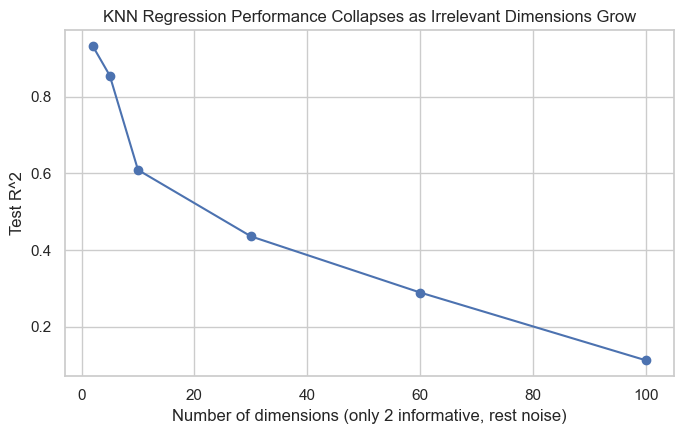

Test R^2 at 2 dimensions: 0.9316 -> at 100 dimensions: 0.1122
-> Only 2 of up to 100 features were ever actually informative -- the same signal, buried in more irrelevant noise dimensions, becomes progressively harder for a distance-based method to find.


In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dimension_df["n_dimensions"], dimension_df["test_R2"], marker="o")
ax.set_xlabel("Number of dimensions (only 2 informative, rest noise)")
ax.set_ylabel("Test R^2")
ax.set_title("KNN Regression Performance Collapses as Irrelevant Dimensions Grow")
plt.tight_layout()
plt.show()
print(f"Test R^2 at 2 dimensions: {dimension_df.iloc[0]['test_R2']:.4f} -> at 100 dimensions: {dimension_df.iloc[-1]['test_R2']:.4f}")
print("-> Only 2 of up to 100 features were ever actually informative -- the same signal, buried in more irrelevant noise dimensions, becomes progressively harder for a distance-based method to find.")


## 8. KNN's Extrapolation Behavior — Contrast With Polynomial Regression

The Polynomial Regression topic found a degree-12 model predicting a physically impossible value just outside its training range. KNN structurally cannot do that -- it can only ever predict an average of training values it has actually seen.


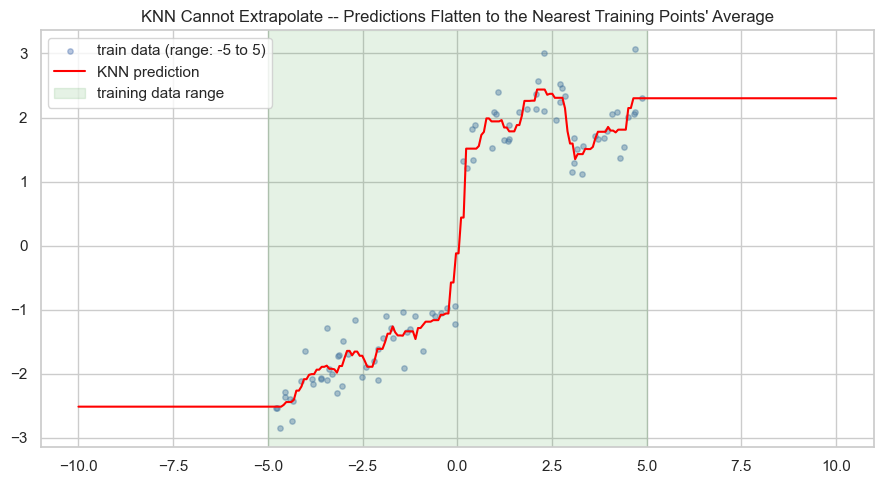

In [23]:
knn_extrap = KNeighborsRegressor(n_neighbors=5).fit(X_1d_train, y_1d_train)
x_extrapolate = np.linspace(-10, 10, 300).reshape(-1, 1)
y_knn_extrap = knn_extrap.predict(x_extrapolate)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.4, s=15, label="train data (range: -5 to 5)")
ax.plot(x_extrapolate, y_knn_extrap, color="red", label="KNN prediction")
ax.axvspan(-5, 5, alpha=0.1, color="green", label="training data range")
ax.set_title("KNN Cannot Extrapolate -- Predictions Flatten to the Nearest Training Points' Average")
ax.legend()
plt.tight_layout()
plt.show()


In [24]:
pred_at_neg10 = knn_extrap.predict([[-10]])[0]
pred_at_10 = knn_extrap.predict([[10]])[0]
pred_at_neg5 = knn_extrap.predict([[-5]])[0]
print(f"Prediction at x=-10 (far outside range): {pred_at_neg10:.3f}")
print(f"Prediction at x=-5 (training range edge): {pred_at_neg5:.3f}")
print(f"Prediction at x=10 (far outside range):  {pred_at_10:.3f}")
print(f"\n-> Predictions at x=-10 and x=-5 are identical ({pred_at_neg10 == pred_at_neg5}) -- KNN just keeps returning the same nearest-neighbor average once past the edge of the data, flat and bounded, structurally unable to produce Polynomial Regression's wild extrapolation failure.")


Prediction at x=-10 (far outside range): -2.514
Prediction at x=-5 (training range edge): -2.514
Prediction at x=10 (far outside range):  2.301

-> Predictions at x=-10 and x=-5 are identical (True) -- KNN just keeps returning the same nearest-neighbor average once past the edge of the data, flat and bounded, structurally unable to produce Polynomial Regression's wild extrapolation failure.


## 9. Tuning `k`, Weights, and Metric Together on Real Data

Applying KNN Regression to the Diabetes dataset with a joint grid search.


In [25]:
knn_param_grid = {
    "n_neighbors": list(range(3, 41, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}
knn_grid_search = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=5, scoring="r2").fit(Xd_train_scaled, yd_train)

print(f"Best params: {knn_grid_search.best_params_}")
print(f"Best CV R^2: {knn_grid_search.best_score_:.4f}")


Best params: {'n_neighbors': 17, 'p': 2, 'weights': 'distance'}
Best CV R^2: 0.4072


In [26]:
cv_results_df = pd.DataFrame(knn_grid_search.cv_results_)[["param_n_neighbors", "param_weights", "param_p", "mean_test_score", "std_test_score"]]
cv_results_df.sort_values("mean_test_score", ascending=False).head(5).reset_index(drop=True)


,param_n_neighbors,param_weights,param_p,mean_test_score,std_test_score
0,17,distance,2,0.407177,0.070237
1,15,distance,2,0.404579,0.076345
2,17,uniform,2,0.402853,0.072001
3,19,distance,2,0.401019,0.071919
4,15,uniform,2,0.400531,0.079349


In [27]:
import time
t0 = time.perf_counter(); KNeighborsRegressor(n_neighbors=3).fit(Xd_train_scaled, yd_train).predict(Xd_test_scaled); k_small_time = time.perf_counter() - t0
t0 = time.perf_counter(); KNeighborsRegressor(n_neighbors=200).fit(Xd_train_scaled, yd_train).predict(Xd_test_scaled); k_large_time = time.perf_counter() - t0
print(f"Fit+predict time, k=3:   {k_small_time*1000:.2f} ms")
print(f"Fit+predict time, k=200: {k_large_time*1000:.2f} ms")
print("-> Unlike parametric methods, KNN has no separate 'training' cost -- prediction time scales with both dataset size and k, since every prediction re-searches the stored training data.")


Fit+predict time, k=3:   1.40 ms
Fit+predict time, k=200: 6.79 ms
-> Unlike parametric methods, KNN has no separate 'training' cost -- prediction time scales with both dataset size and k, since every prediction re-searches the stored training data.


In [28]:
knn_best_test_r2 = r2_score(yd_test, knn_grid_search.predict(Xd_test_scaled))
knn_train_r2 = r2_score(yd_train, knn_grid_search.predict(Xd_train_scaled))
print(f"Train R^2: {knn_train_r2:.4f}")
print(f"Test R^2:  {knn_best_test_r2:.4f}")
print(f"Gap: {knn_train_r2 - knn_best_test_r2:.4f}  ({'small, not much overfitting' if knn_train_r2 - knn_best_test_r2 < 0.15 else 'notable gap'})")


Train R^2: 1.0000
Test R^2:  0.4708
Gap: 0.5292  (notable gap)


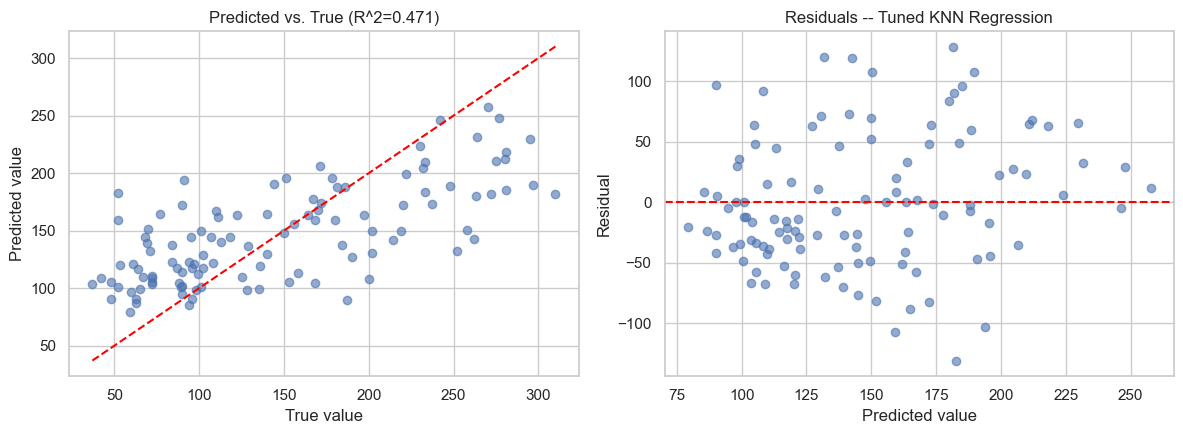

In [29]:
knn_pred_diabetes = knn_grid_search.predict(Xd_test_scaled)
residuals_knn = yd_test - knn_pred_diabetes

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yd_test, knn_pred_diabetes, alpha=0.6)
lims = [min(yd_test.min(), knn_pred_diabetes.min()), max(yd_test.max(), knn_pred_diabetes.max())]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("True value"); axes[0].set_ylabel("Predicted value"); axes[0].set_title(f"Predicted vs. True (R^2={knn_best_test_r2:.3f})")

axes[1].scatter(knn_pred_diabetes, residuals_knn, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals -- Tuned KNN Regression")
plt.tight_layout()
plt.show()


## 10. Comparison Against Every Prior Regression Method in This Category

Continuing this category's running comparison table with KNN added.


In [30]:
ridge_diabetes = Ridge(alpha=10.0).fit(Xd_train_scaled, yd_train)
linear_diabetes = LinearRegression().fit(Xd_train_scaled, yd_train)
svr_diabetes = SVR(kernel="rbf", C=100, epsilon=1.0, gamma=0.01).fit(Xd_train_scaled, yd_train)

category_comparison = pd.DataFrame([
    {"Model": "Linear Regression (topic 01)", "Test R2": round(r2_score(yd_test, linear_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "Ridge (topic 03)", "Test R2": round(r2_score(yd_test, ridge_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "SVR, RBF, tuned (topic 04)", "Test R2": round(r2_score(yd_test, svr_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "KNN Regression, tuned (this topic)", "Test R2": round(knn_best_test_r2, 4)},
]).set_index("Model")
category_comparison


,Test R2
Model,
Linear Regression (topic 01),0.4849
Ridge (topic 03),0.4881
"SVR, RBF, tuned (topic 04)",0.4925
"KNN Regression, tuned (this topic)",0.4708


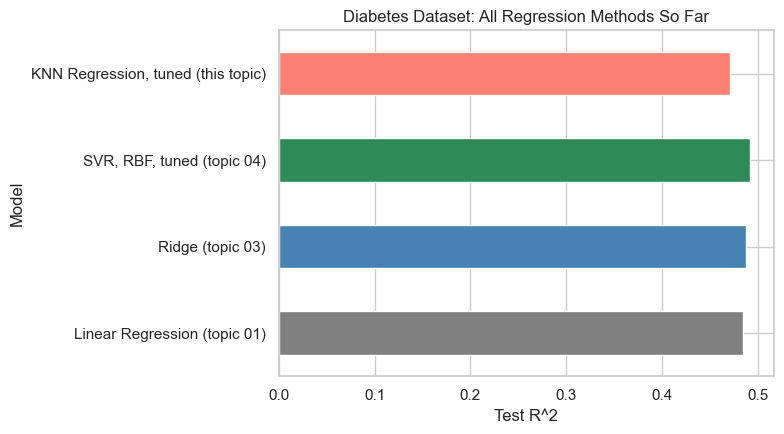

Best so far on this dataset: SVR, RBF, tuned (topic 04) (0.4925)


In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
category_comparison["Test R2"].plot(kind="barh", ax=ax, color=["gray", "steelblue", "seagreen", "salmon"])
ax.set_xlabel("Test R^2")
ax.set_title("Diabetes Dataset: All Regression Methods So Far")
plt.tight_layout()
plt.show()

best_model = category_comparison["Test R2"].idxmax()
print(f"Best so far on this dataset: {best_model} ({category_comparison['Test R2'].max():.4f})")


## 11. Summary

KNN Regression is the most structurally different method covered in this category so far: no coefficients, no support vectors, no training phase beyond storing data -- every prediction is recomputed from scratch by averaging nearby observed values. This gives it two properties unique among this category's methods: it can represent genuinely discontinuous relationships (Section 2's step curve) without any special handling, and it structurally cannot extrapolate wildly (Section 8, in direct contrast to Polynomial Regression's failure mode). Its core weakness -- the curse of dimensionality (Section 7) -- is the same one first measured for KNN Classification, now confirmed to affect regression identically.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
